In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# 1

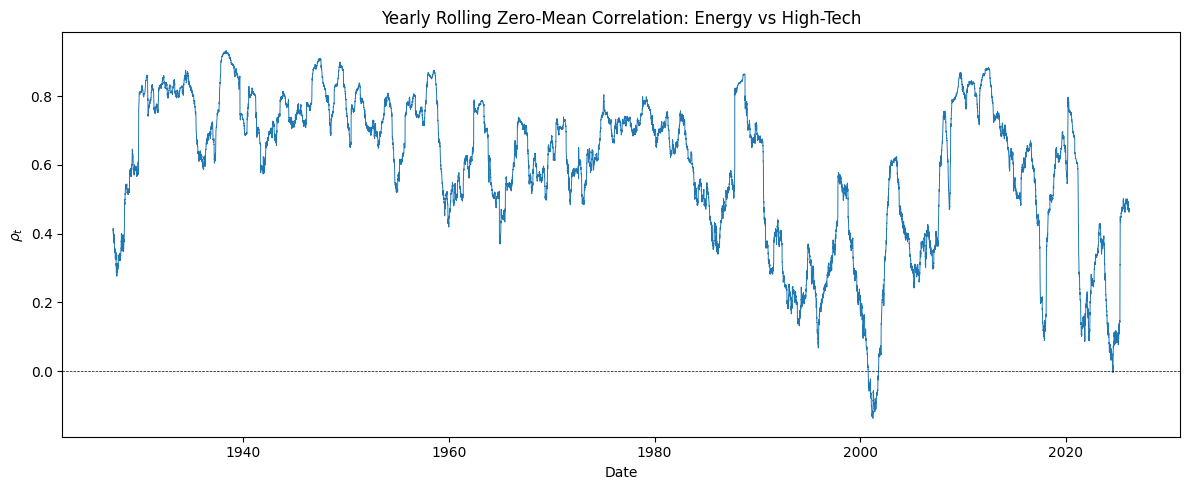

In [6]:
df = pd.read_csv('data.csv')
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

r_e = df['Enrgy'].values
r_ht = df['HiTec'].values

window = 252
n = len(r_e)
rho = np.full(n, np.nan)

for t in range(window, n):
    re_w = r_e[t - window:t]
    rht_w = r_ht[t - window:t]
    cov = np.mean(re_w * rht_w)
    vol_e = np.sqrt(np.mean(re_w**2))
    vol_ht = np.sqrt(np.mean(rht_w**2))
    rho[t] = cov / (vol_e * vol_ht)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], rho, linewidth=0.7)
ax.set_xlabel('Date')
ax.set_ylabel(r'$\rho_t$')
ax.set_title('Yearly Rolling Zero-Mean Correlation: Energy vs High-Tech')
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
fig.tight_layout()
plt.show()


In [8]:
mean_rho = np.nanmean(rho)
median_rho = np.nanmedian(rho)
q05 = np.nanquantile(rho, 0.05)
q95 = np.nanquantile(rho, 0.95)

print(f'mean: {mean_rho}, median: {median_rho}, q05: {q05}, q95: {q95}')

mean: 0.6014495772586683, median: 0.6561367093153252, q05: 0.1815636378876086, q95: 0.8605484800941082


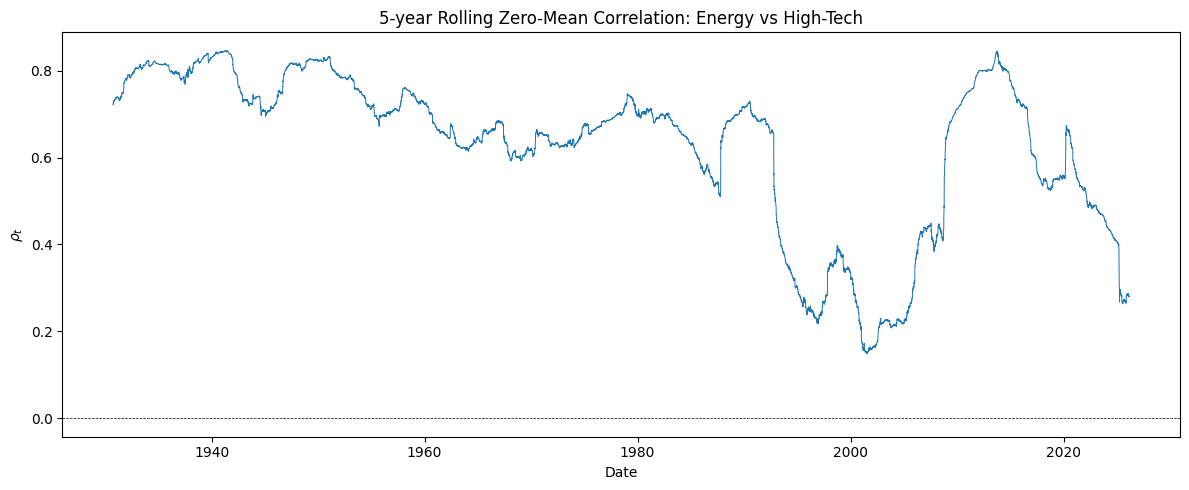

mean: 0.633566553871756, median: 0.6853455933577199, q05: 0.23618785938232195, q95: 0.8247170970742468


In [9]:
df = pd.read_csv('data.csv')
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

r_e = df['Enrgy'].values
r_ht = df['HiTec'].values

window = 252 * 5
n = len(r_e)
rho = np.full(n, np.nan)

for t in range(window, n):
    re_w = r_e[t - window:t]
    rht_w = r_ht[t - window:t]
    cov = np.mean(re_w * rht_w)
    vol_e = np.sqrt(np.mean(re_w**2))
    vol_ht = np.sqrt(np.mean(rht_w**2))
    rho[t] = cov / (vol_e * vol_ht)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], rho, linewidth=0.7)
ax.set_xlabel('Date')
ax.set_ylabel(r'$\rho_t$')
ax.set_title('5-year Rolling Zero-Mean Correlation: Energy vs High-Tech')
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
fig.tight_layout()
plt.show()

mean_rho = np.nanmean(rho)
median_rho = np.nanmedian(rho)
q05 = np.nanquantile(rho, 0.05)
q95 = np.nanquantile(rho, 0.95)

print(f'mean: {mean_rho}, median: {median_rho}, q05: {q05}, q95: {q95}')